In [1]:
# ====== Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import missingno
import joblib

In [2]:
# ====== Set pandas options
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [3]:
# ====== Load the customer data
df = pd.read_csv("./Telco-Customer-Churn.csv")
display(df.head(5))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# ====== Display the information on the data
display(df.info())
display(df.sample(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6455,2478-EEWWM,Male,0,Yes,No,59,No,No phone service,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.30,2666.75,No
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
2074,6179-GJPSO,Female,1,No,No,43,Yes,No,Fiber optic,Yes,Yes,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),108.15,4600.7,Yes
6099,7711-GQBZC,Female,0,Yes,Yes,71,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),24.70,1810.55,No
237,9903-LYSAB,Male,0,Yes,No,18,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,73.15,1305.95,No
951,8584-KMVXD,Female,0,No,No,8,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,No,Electronic check,75.60,535.55,No
2307,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,No
2448,9221-OTIVJ,Female,1,No,No,14,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,104.85,1531.4,Yes
2974,1481-ZUWZA,Male,0,No,No,28,Yes,Yes,Fiber optic,Yes,Yes,No,No,No,Yes,Month-to-month,Yes,Credit card (automatic),94.50,2659.4,Yes
6255,4476-OSWTN,Male,1,Yes,No,69,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,110.55,7610.1,No


Seeing that 'TotalCharges' is an object, versus the float format that is expected, lets look more into these values.

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

<Axes: >

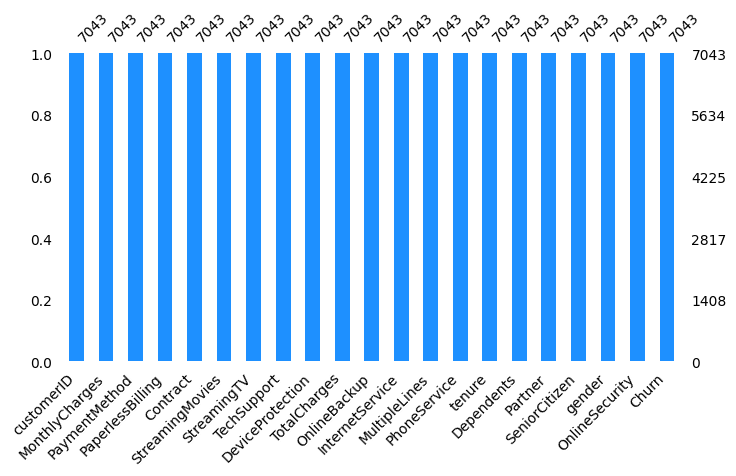

In [5]:
# ====== Check for missing values
display(df.isna().any(axis=0))
display(missingno.bar(df, color="dodgerblue", sort="ascending", figsize=(8,4), fontsize=10))

In [6]:
# ====== Inspecting the values for 'TotalCharges'
display(df['TotalCharges'].sort_values())
display(df['TotalCharges'].unique())

936           
3826          
4380          
753           
5218          
         ...  
6646    997.75
5598     998.1
3686    999.45
3353     999.8
2845     999.9
Name: TotalCharges, Length: 7043, dtype: object

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [7]:
# ====== Inspecting the values for 'TotalCharges'
display(df['TotalCharges'].iloc[[936, 3826, 4380, 753, 5218]])

936      
3826     
4380     
753      
5218     
Name: TotalCharges, dtype: object

We'll force coerce the non-numeric values and replace them with the median for 'TotalCharges'

In [8]:
# ====== Handle any missing values or data irregularities
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

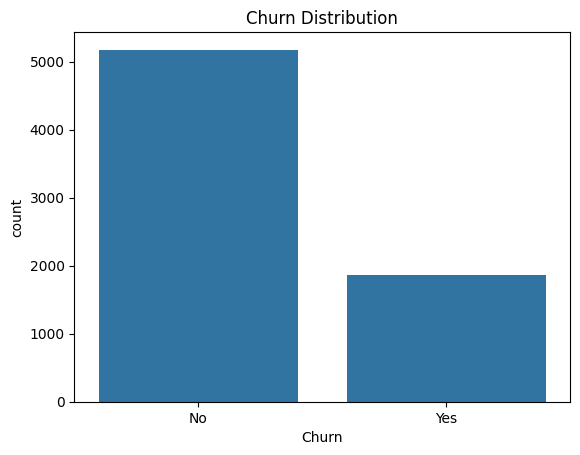

In [9]:
# ====== Visualize churn distribution
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

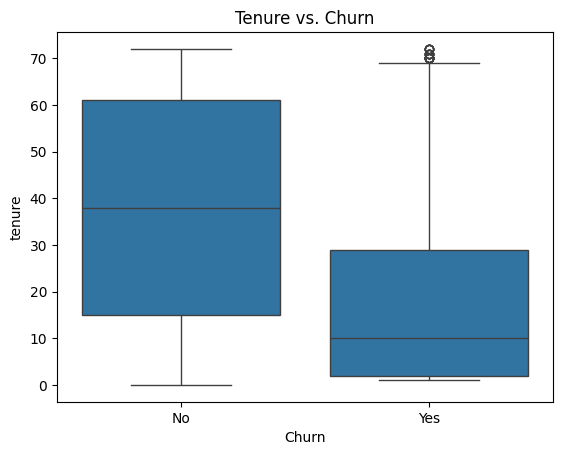

In [10]:
# ====== Churn vs. Tenure
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs. Churn')
plt.show()

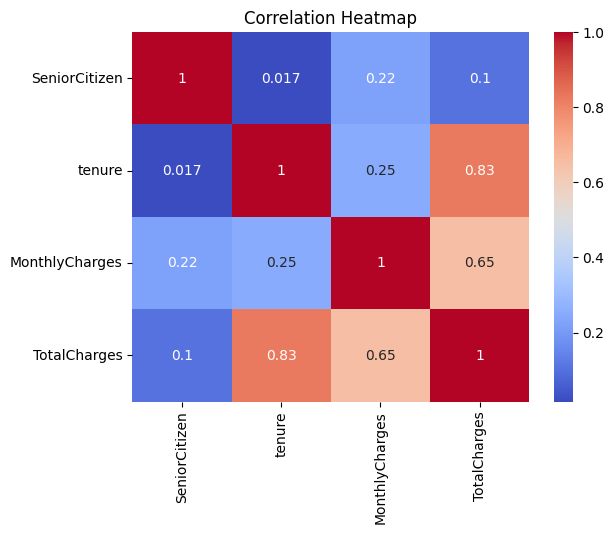

In [11]:
# ====== Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [12]:
# ====== Define target (y) before encodin
y = df['Churn'].map({'No': 0, 'Yes': 1})

In [13]:
# ====== Identify all categorical columns (excluding customerID and Churn)
categorical_cols = df.select_dtypes(include=['object']).columns.drop(['customerID', 'Churn'])

In [14]:
# ====== Apply one-hot encoding to all categorical columns
df_encoded = pd.get_dummies(df.drop(['customerID', 'Churn'], axis=1), columns=categorical_cols, drop_first=True)

In [15]:
# ====== Define features (X) 
X = df_encoded

In [16]:
# ====== Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# ====== Scale numeric features
scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [18]:
# ====== Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
# ====== Make predictions
y_pred = rf_model.predict(X_test)

In [20]:
# ====== Evaluate the model
display("Accuracy:", round(accuracy_score(y_test, y_pred),4))
print("Classification Report:", classification_report(y_test, y_pred))

'Accuracy:'

0.7899

Classification Report:               precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



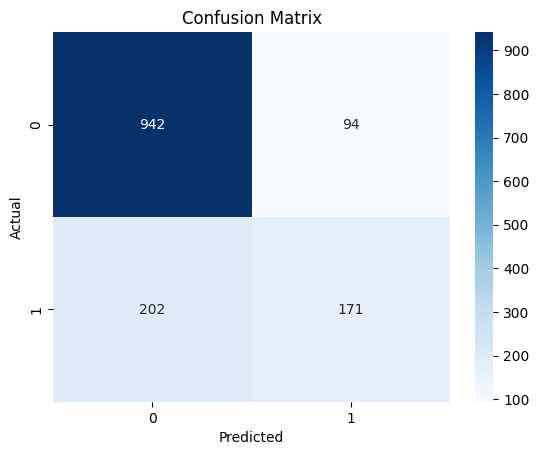

In [21]:
# ====== Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

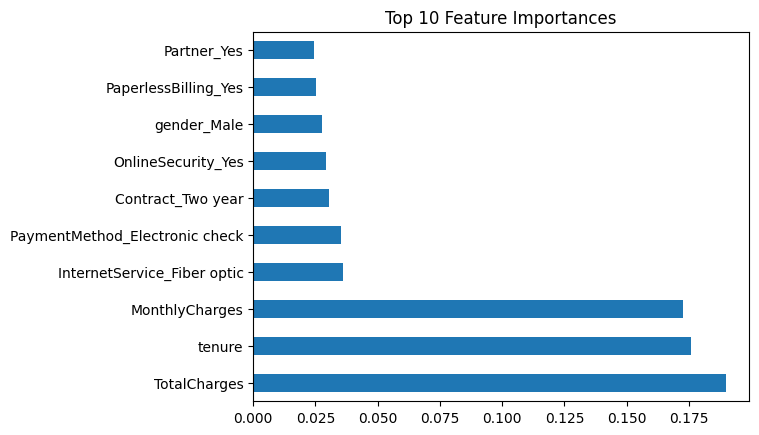

In [22]:
# ====== Feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_importance[:10].plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.show()

In [23]:
# ====== Save model to a pickle file (for cloud upload)
joblib.dump(rf_model, 'rf_churn_model.pkl')

['rf_churn_model.pkl']

Let's take a look at hyperparameter tuning of the model

In [24]:
# ====== Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# ====== Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],           # Test 50, 100, and 200 trees
    'max_depth': [None, 10, 20],              # No limit, 10, or 20 levels
    'min_samples_split': [2, 5, 10],          # Minimum samples to split
    'min_samples_leaf': [1, 2, 4]             # Minimum samples per leaf
}

In [25]:
# ====== Initialize the base model
rf_model = RandomForestClassifier(random_state=42)

# ====== Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # Optimize for accuracy (could use 'f1' for imbalanced data)
    n_jobs=-1,               # Use all available CPU cores
    verbose=1                # Show progress
)

In [26]:
# ====== Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [27]:
# ====== Print the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validation Score: 0.8042236340053049


In [28]:
# ====== Use the best model for predictions
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

Compare the best tuned models

In [29]:
# ====== Evaluate the optimized model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ====== Calculate and print metrics
print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Test Set Accuracy: 0.8112136266855926
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



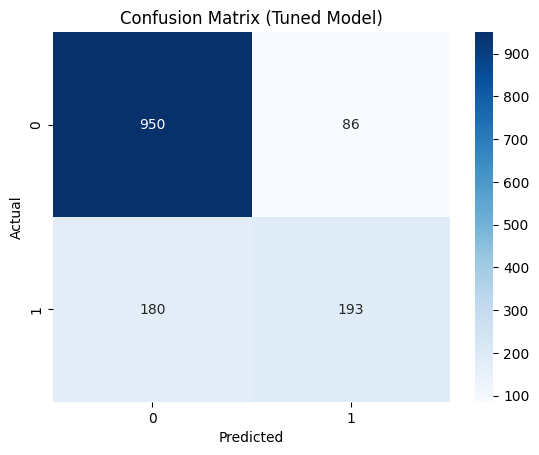

In [30]:
# ====== Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Tuned Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

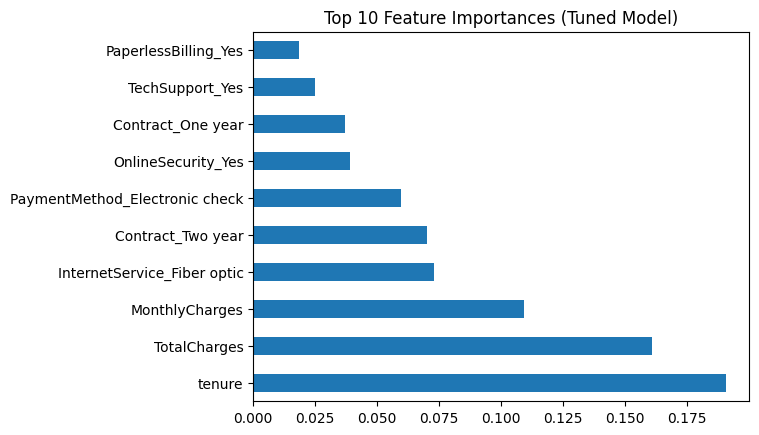

In [31]:
# ====== Feature importance (optional)
importances = best_rf_model.feature_importances_
feature_names = X_train.columns
feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feat_importance[:10].plot(kind='barh')
plt.title('Top 10 Feature Importances (Tuned Model)')
plt.show()

In [32]:
# ====== Save the tuned model and scaler
joblib.dump(best_rf_model, 'rf_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved successfully!")

Model and scaler saved successfully!
